# Ahmed Ragheb - Data Preprocessing, EDA, and Feature Engineering

This notebook contains the shared data pipeline used by the three final project models:

1. Dataset loading
2. Dataset exploration
3. Class distribution
4. Sample images
5. CLAHE enhancement and denoising
6. Train/validation/test split
7. Class weights
8. Submission checklist for preprocessing requirements


## 1. Install Required Libraries

In [1]:
!pip -q install kagglehub opencv-python-headless scikit-image


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Imports and Settings

In [2]:
import os
import math
import json
import random
from pathlib import Path

import cv2
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import load_img, img_to_array

from xaai_notebook_utils import cap_dataframe_per_class, get_output_dir, resolve_dataset_path

SEED = 42
IMG_SIZE = 224
OUTPUT_DIR = get_output_dir("preprocessing_eda")
DATASET_ID = "fernando2rad/x-ray-lung-diseases-images-9-classes"
MAX_SAMPLES_PER_CLASS = int(os.environ.get("XAAI_MAX_SAMPLES_PER_CLASS", "0"))

random.seed(SEED)
np.random.seed(SEED)

print("Output directory:", OUTPUT_DIR)
print("MAX_SAMPLES_PER_CLASS:", MAX_SAMPLES_PER_CLASS)


Output directory: C:\Users\ahmed\Desktop\xaai\artifacts\preprocessing_eda_final_outputs
MAX_SAMPLES_PER_CLASS: 0


C:\Users\ahmed\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


## 3. Dataset Loading

In [3]:
dataset_path, using_local_override = resolve_dataset_path(DATASET_ID, kagglehub.dataset_download)
if using_local_override:
    print("Using dataset from XAAI_DATASET_ROOT:", dataset_path)
else:
    print("Downloaded dataset path:", dataset_path)


Using dataset from XAAI_DATASET_ROOT: C:\Users\ahmed\.cache\kagglehub\datasets\fernando2rad\x-ray-lung-diseases-images-9-classes\versions\1


## 4. Build DataFrame

In [4]:
VALID_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".webp"}

def is_image_file(path):
    return Path(path).suffix.lower() in VALID_EXTS

def count_images(folder: Path):
    return sum(1 for p in folder.rglob("*") if p.is_file() and is_image_file(p))

def find_dataset_root(base_path: str):
    base = Path(base_path)
    direct_subdirs = [p for p in base.iterdir() if p.is_dir()]
    direct_valid = [p for p in direct_subdirs if count_images(p) > 0]
    if len(direct_valid) >= 2:
        return base

    best = None
    best_score = -1
    for root, dirs, files in os.walk(base):
        root_path = Path(root)
        child_dirs = [root_path / d for d in dirs]
        score = sum(count_images(d) > 0 for d in child_dirs)
        if score > best_score and score >= 2:
            best = root_path
            best_score = score

    if best is None:
        raise FileNotFoundError("Could not detect dataset root.")
    return best

def build_dataframe(dataset_root: Path):
    rows = []
    class_dirs = sorted([p for p in dataset_root.iterdir() if p.is_dir()], key=lambda x: x.name.lower())
    for class_dir in class_dirs:
        for img_path in class_dir.rglob("*"):
            if img_path.is_file() and is_image_file(img_path):
                rows.append({"filepath": str(img_path), "label": class_dir.name})
    return pd.DataFrame(rows)

DATASET_ROOT = find_dataset_root(dataset_path)
df = build_dataframe(DATASET_ROOT)

if MAX_SAMPLES_PER_CLASS > 0:
    df = cap_dataframe_per_class(df, "label", MAX_SAMPLES_PER_CLASS, SEED)
    print("Applied per-class cap:", MAX_SAMPLES_PER_CLASS)

print("Dataset root:", DATASET_ROOT)
print("Total images:", len(df))
display(df.head())
print("Classes:", sorted(df["label"].unique()))


Dataset root: C:\Users\ahmed\.cache\kagglehub\datasets\fernando2rad\x-ray-lung-diseases-images-9-classes\versions\1
Total images: 6743


,filepath,label
0,C:\Users\ahmed\.cache\kagglehub\datasets\ferna...,00 Anatomia Normal
1,C:\Users\ahmed\.cache\kagglehub\datasets\ferna...,00 Anatomia Normal
2,C:\Users\ahmed\.cache\kagglehub\datasets\ferna...,00 Anatomia Normal
3,C:\Users\ahmed\.cache\kagglehub\datasets\ferna...,00 Anatomia Normal
4,C:\Users\ahmed\.cache\kagglehub\datasets\ferna...,00 Anatomia Normal


Classes: ['00 Anatomia Normal', '01 Processos Inflamatórios Pulmonares (Pneumonia)', '02 Maior Densidade (Derrame Pleural, Consolidação Atelectasica, Hidrotorax, Empiema)', '03 Menor Densidade (Pneumotorax, Pneumomediastino, Pneumoperitonio)', '04 Doenças Pulmonares Obstrutivas (Enfisema, Broncopneumonia, Bronquiectasia, Embolia)', '05 Doenças Infecciosas Degenerativas (Tuberculose, Sarcoidose, Proteinose, Fibrose)', '06 Lesões Encapsuladas (Abscessos, Nódulos, Cistos, Massas Tumorais, Metastases)', '07 Alterações de Mediastino (Pericardite, Malformações Arteriovenosas, Linfonodomegalias)', '08 Alterações do Tórax (Atelectasias, Malformações, Agenesia, Hipoplasias)']


## 5. Class Distribution and Sample Images

,Image Count
label,
00 Anatomia Normal,1340
01 Processos Inflamatórios Pulmonares (Pneumonia),1060
"02 Maior Densidade (Derrame Pleural, Consolidação Atelectasica, Hidrotorax, Empiema)",678
"03 Menor Densidade (Pneumotorax, Pneumomediastino, Pneumoperitonio)",629
"04 Doenças Pulmonares Obstrutivas (Enfisema, Broncopneumonia, Bronquiectasia, Embolia)",644
"05 Doenças Infecciosas Degenerativas (Tuberculose, Sarcoidose, Proteinose, Fibrose)",594
"06 Lesões Encapsuladas (Abscessos, Nódulos, Cistos, Massas Tumorais, Metastases)",658
"07 Alterações de Mediastino (Pericardite, Malformações Arteriovenosas, Linfonodomegalias)",596
"08 Alterações do Tórax (Atelectasias, Malformações, Agenesia, Hipoplasias)",544


C:\Users\ahmed\AppData\Local\Temp\ipykernel_13456\1664978698.py:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


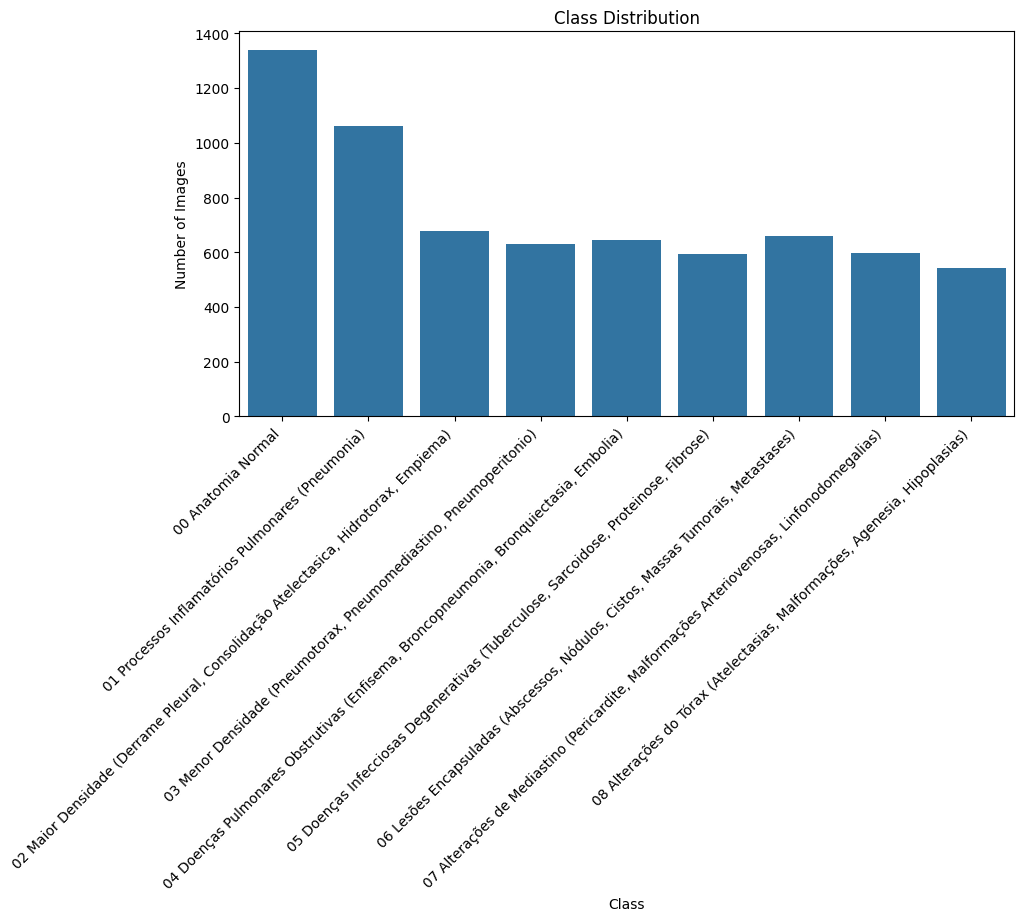

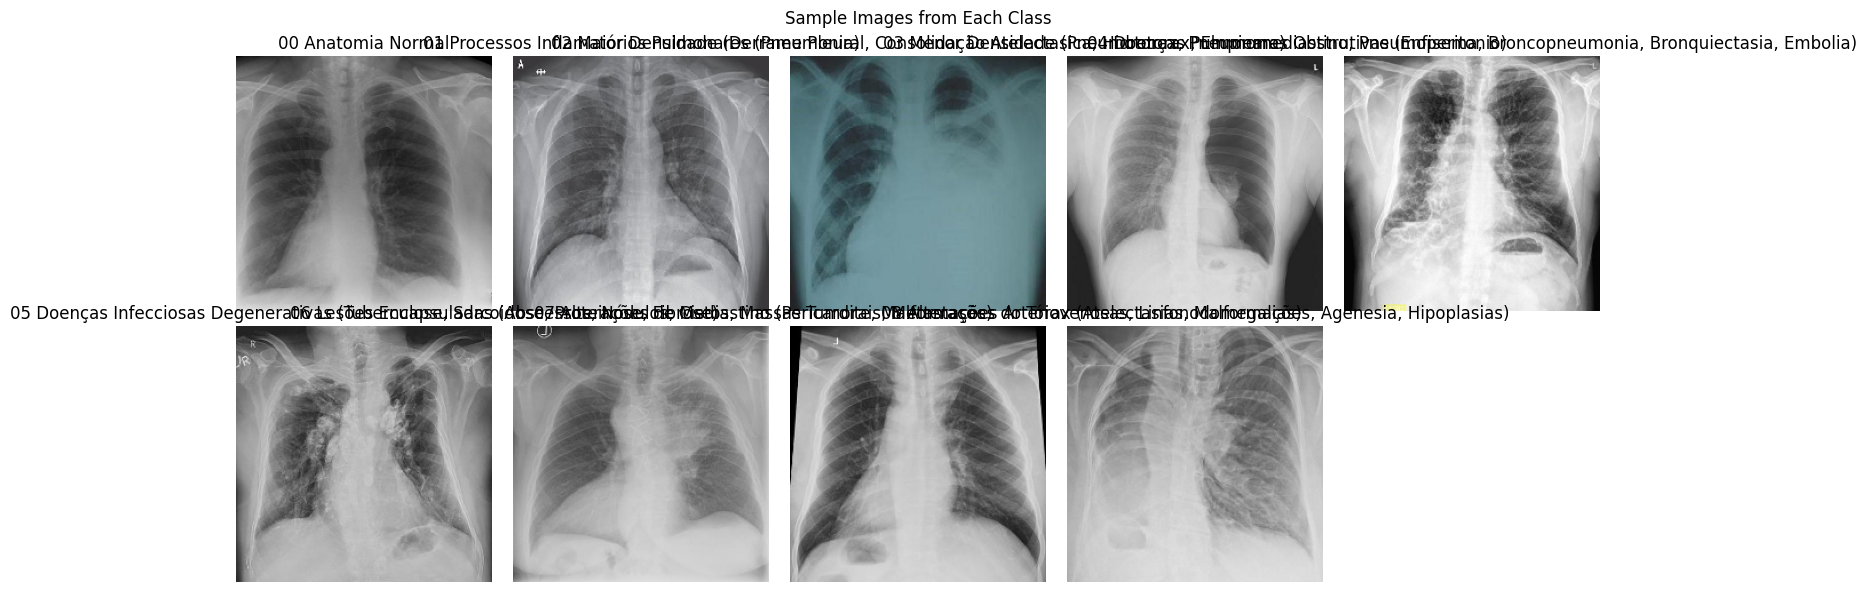

In [5]:
class_counts = df["label"].value_counts().sort_index()
display(class_counts.to_frame("Image Count"))

plt.figure(figsize=(10, 5))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

sample_df = df.groupby("label").sample(1, random_state=SEED).reset_index(drop=True)

plt.figure(figsize=(14, 6))
for i, row in sample_df.iterrows():
    img = load_img(row["filepath"], target_size=(IMG_SIZE, IMG_SIZE))
    plt.subplot(2, math.ceil(len(sample_df) / 2), i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(row["label"])
    plt.axis("off")
plt.suptitle("Sample Images from Each Class")
plt.tight_layout()
plt.show()


## 6. CLAHE Enhancement and Denoising

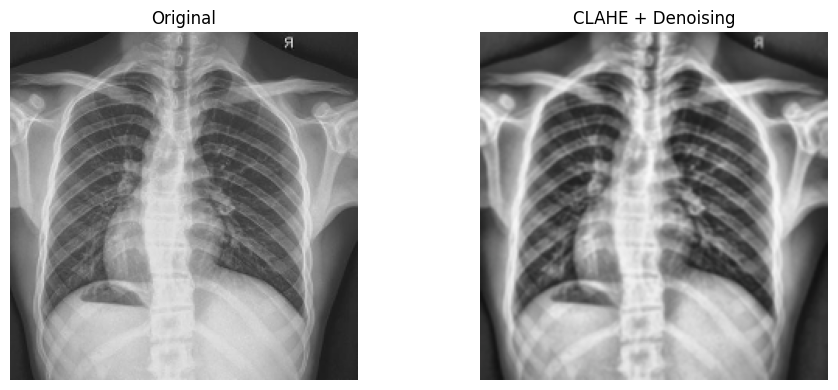

In [6]:
def clahe_rgb_uint8(img):
    img = img.astype("uint8")
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l2 = clahe.apply(l)
    enhanced = cv2.cvtColor(cv2.merge((l2, a, b)), cv2.COLOR_LAB2RGB)
    enhanced = cv2.GaussianBlur(enhanced, (3, 3), 0)
    return enhanced

example_path = df.iloc[0]["filepath"]
original = img_to_array(load_img(example_path, target_size=(IMG_SIZE, IMG_SIZE))).astype("uint8")
enhanced = clahe_rgb_uint8(original)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(enhanced)
plt.title("CLAHE + Denoising")
plt.axis("off")

plt.tight_layout()
plt.show()


## 7. Train, Validation, and Test Split

In [7]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

display(pd.DataFrame({
    "Train": train_df["label"].value_counts(),
    "Validation": val_df["label"].value_counts(),
    "Test": test_df["label"].value_counts()
}).fillna(0).astype(int))

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))


,Train,Validation,Test
label,,,
00 Anatomia Normal,938,201,201
01 Processos Inflamatórios Pulmonares (Pneumonia),742,159,159
"02 Maior Densidade (Derrame Pleural, Consolidação Atelectasica, Hidrotorax, Empiema)",474,102,102
"06 Lesões Encapsuladas (Abscessos, Nódulos, Cistos, Massas Tumorais, Metastases)",461,98,99
"04 Doenças Pulmonares Obstrutivas (Enfisema, Broncopneumonia, Bronquiectasia, Embolia)",451,96,97
"03 Menor Densidade (Pneumotorax, Pneumomediastino, Pneumoperitonio)",440,94,95
"07 Alterações de Mediastino (Pericardite, Malformações Arteriovenosas, Linfonodomegalias)",417,90,89
"05 Doenças Infecciosas Degenerativas (Tuberculose, Sarcoidose, Proteinose, Fibrose)",416,89,89
"08 Alterações do Tórax (Atelectasias, Malformações, Agenesia, Hipoplasias)",381,82,81


Train: 4720
Validation: 1011
Test: 1012


## 8. Class Weights

In [8]:
class_names = sorted(train_df["label"].unique())
class_to_index = {label: idx for idx, label in enumerate(class_names)}
y_train_labels = train_df["label"].map(class_to_index).values

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_labels),
    y=y_train_labels
)

class_weight_df = pd.DataFrame({
    "Class": class_names,
    "Weight": [float(w) for w in weights]
})

display(class_weight_df)


,Class,Weight
0,00 Anatomia Normal,0.559109
1,01 Processos Inflamatórios Pulmonares (Pneumonia),0.706798
2,"02 Maior Densidade (Derrame Pleural, Consolida...",1.106423
3,"03 Menor Densidade (Pneumotorax, Pneumomediast...",1.191919
4,"04 Doenças Pulmonares Obstrutivas (Enfisema, B...",1.162848
5,05 Doenças Infecciosas Degenerativas (Tubercul...,1.260684
6,"06 Lesões Encapsuladas (Abscessos, Nódulos, Ci...",1.137624
7,"07 Alterações de Mediastino (Pericardite, Malf...",1.257661
8,"08 Alterações do Tórax (Atelectasias, Malforma...",1.376495


## 9. Save Summary

In [9]:
summary = {
    "dataset_root": str(DATASET_ROOT),
    "total_images": int(len(df)),
    "classes": class_names,
    "train_size": int(len(train_df)),
    "validation_size": int(len(val_df)),
    "test_size": int(len(test_df)),
    "max_samples_per_class": int(MAX_SAMPLES_PER_CLASS)
}

with open(OUTPUT_DIR / "preprocessing_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Saved summary to:", OUTPUT_DIR / "preprocessing_summary.json")


Saved summary to: C:\Users\ahmed\Desktop\xaai\artifacts\preprocessing_eda_final_outputs\preprocessing_summary.json


## 10. Requirement Checklist

In [10]:
checklist_df = pd.DataFrame({
    "Requirement": [
        "Dataset loading",
        "Data exploration",
        "Class distribution",
        "Sample images",
        "Image preprocessing",
        "CLAHE enhancement",
        "Denoising",
        "Train/validation/test split",
        "Class weights"
    ],
    "Status": ["Done"] * 9
})

display(checklist_df)
print("Preprocessing notebook completed successfully.")


,Requirement,Status
0,Dataset loading,Done
1,Data exploration,Done
2,Class distribution,Done
3,Sample images,Done
4,Image preprocessing,Done
5,CLAHE enhancement,Done
6,Denoising,Done
7,Train/validation/test split,Done
8,Class weights,Done


Preprocessing notebook completed successfully.
